---
format:
    html: default
    ipynb: default
jupyter: python3
---


## Explaining CNNs


In this assignment you implement two explainer algorithms for Convolutional Neural Networks (CNNs) and use them to inspect a model you have already trained. An explainer answers a question that accuracy alone cannot: which parts of an input drove this particular prediction? For an image classifier that answer takes the form of a saliency map, and a trustworthy map should highlight the animal rather than the background, a watermark, or some dataset artifact the model latched onto.

We invite you to watch the following video, which sets the context and walks through the tools you can use. Click the thumbnail to open it on YouTube.

[![Watch the assignment introduction on YouTube](https://img.youtube.com/vi/Am2EF9CLu-g/hqdefault.jpg)](https://www.youtube.com/watch?v=Am2EF9CLu-g)

In the [cats vs dogs](https://huggingface.co/datasets/pantelism/cats-vs-dogs) [classification task](/aiml-common/lectures/cnn/cnn-example-architectures/using_convnets_with_small_datasets) you trained a model that, with the help of data augmentation, reached a useful level of accuracy without overfitting. That trained model is your subject here. You do not retrain it or change its architecture; you attach explainers to it and interpret what they reveal about how it decides.

### The two methods you will implement

**Integrated gradients** ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)) attributes a prediction to individual input pixels. It picks a baseline image (commonly an all-black image, which the model should find uninformative) and integrates the gradient of the class score along the straight-line path from that baseline to the actual input. The result is a per-pixel attribution with two properties that plain input gradients lack: completeness, meaning the attributions sum to the difference in model output between the input and the baseline, and robustness to saturated activations, where a plain gradient would read close to zero even though the feature mattered.

**Grad-CAM** ([Selvaraju et al., 2016](https://arxiv.org/abs/1610.02391)) produces a coarse, class-discriminative heatmap. It takes the feature maps of a convolutional layer, usually the last one, and weights each map by the gradient of the class score flowing into it. Because it works at the resolution of a deep feature map rather than the raw pixels, it localizes the region the network used instead of scoring every pixel.

The two methods sit at opposite ends of a resolution trade-off: integrated gradients is fine-grained and pixel-level, Grad-CAM is coarse and region-level. Running both on the same image and noting where they agree, and where they do not, is the heart of this assignment.

We strongly advise PyTorch with [Captum](https://captum.ai/tutorials/) unless you already have Keras/TF expertise, because both methods ship as ready implementations there (`IntegratedGradients` and `LayerGradCam`). You are free to use the high-level APIs of the framework of your choice.

### What to submit

For each method, in the cells below:

- A markdown explanation written so that anyone who understands how a CNN works can follow it. Cover the intuition, the role of the baseline (integrated gradients) or the target layer (Grad-CAM), and one limitation of the method.
- Working code that runs the explainer on at least three correctly classified images and at least one image the model got wrong.
- The resulting maps overlaid on the input images, each with a one-line caption stating what the map suggests the model attended to.

### How your work is evaluated

- Correctness: the right baseline, the right target layer, and gradients taken with respect to the predicted class rather than a fixed label.
- Visualization quality: maps are overlaid on the inputs, readable, and labeled.
- Depth of interpretation: noting that a map "looks reasonable" is not enough. Point to where the two methods agree, where they disagree, and what the misclassified example tells you about what the model actually learned.

In [63]:
pip install captum datasets torchvision

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [64]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from datasets import load_dataset
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

IMG_SIZE    = 150
MEAN        = [0.5, 0.5, 0.5]
STD         = [0.5, 0.5, 0.5]
label_names = ["cat", "dog"]
SEED        = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [65]:
class SmallConvNet(nn.Module):
    def __init__(self, dropout: bool = False):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32,  3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5) if dropout else nn.Identity(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)

model = SmallConvNet(dropout=True).to(DEVICE)
model.load_state_dict(torch.load("cats_and_dogs_small.pth", map_location=DEVICE))
model.eval()

SmallConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=6272, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [66]:
class TwoLogitWrapper(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, x):
        z = self.base(x).unsqueeze(1)
        return torch.cat([-z, z], dim=1)

wrapped = TwoLogitWrapper(model).to(DEVICE).eval()
target_layer = model.features[9]

In [67]:
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def denormalize(t):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (t.detach().cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

def predict(x):
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    return int(p > 0.5), p

In [68]:
torch.manual_seed(SEED)
ds = load_dataset("pantelism/cats-vs-dogs")["test"]

correct, wrong = [], []
for i in range(len(ds)):
    sample = ds[i]
    img    = sample["image"].convert("RGB")
    true   = int(sample["label"])
    x      = eval_tf(img).unsqueeze(0).to(DEVICE)
    pred, prob = predict(x)
    record = dict(x=x, true=true, pred=pred, prob=prob, pil=img)
    (correct if pred == true else wrong).append(record)
    if len(correct) >= 3 and len(wrong) >= 1:
        break

examples = correct[:3] + wrong[:1]
for r in examples:
    tag = "✓" if r["pred"] == r["true"] else "✗ MISCLASSIFIED"
    print(f"true={label_names[r['true']]:>3}  pred={label_names[r['pred']]:>3}  "
          f"P(dog)={r['prob']:.3f}  {tag}")

true=cat  pred=cat  P(dog)=0.146  ✓
true=cat  pred=cat  P(dog)=0.483  ✓
true=cat  pred=cat  P(dog)=0.163  ✓
true=cat  pred=dog  P(dog)=0.952  ✗ MISCLASSIFIED


Method 1: Integrated Gradients

Integrated Gradients scores how much each pixel contributed to the prediction. It starts from a blank baseline image and moves in a straight line to the real image and adds up the gradients. Pixels the model relied on build up a high score.

The baseline is the blank image the method compares against which is usually all black. The attribution measures what changes as you go from this empty baseline to the real input.

The result depends on the baseline you choose. A different baseline can give different attributions for the same image, so the explanation is relative to that choice rather than an absolute fact.

In [69]:
ig = IntegratedGradients(wrapped)

def integrated_gradients_map(x, target):
    baseline = (torch.zeros_like(x) - 0.5) / 0.5
    attr = ig.attribute(x, baselines=baseline, target=target, n_steps=50)
    attr = attr.squeeze(0).detach().cpu().numpy()
    attr = np.abs(attr).sum(axis=0)
    return attr / (attr.max() + 1e-8)

In [70]:
def show_overlay(record, attr, method, cmap="jet", alpha=0.5):
    base = denormalize(record["x"].squeeze(0))
    fig, ax = plt.subplots(1, 3, figsize=(11, 4))
    ax[0].imshow(base);            ax[0].set_title("input")
    ax[1].imshow(attr, cmap=cmap); ax[1].set_title(f"{method} map")
    ax[2].imshow(base)
    ax[2].imshow(attr, cmap=cmap, alpha=alpha); ax[2].set_title("overlay")
    for a in ax: a.axis("off")
    verdict = "correct" if record["pred"] == record["true"] else "MISCLASSIFIED"
    fig.suptitle(
        f"true={label_names[record['true']]}  "
        f"pred={label_names[record['pred']]}  "
        f"P(dog)={record['prob']:.2f}  [{verdict}]", fontsize=11)
    plt.tight_layout(); plt.show()

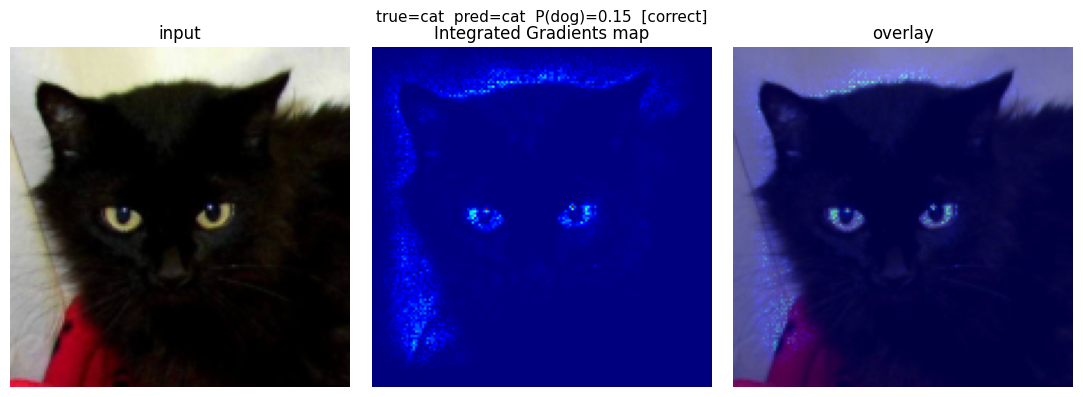

In [71]:
# Integrated Gradients: image 1
r = examples[0]
ig_maps = [integrated_gradients_map(r["x"], target=r["pred"])]
show_overlay(r, ig_maps[0], method="Integrated Gradients")

Attribution sits on the eyes and ear outline. The model read the face.

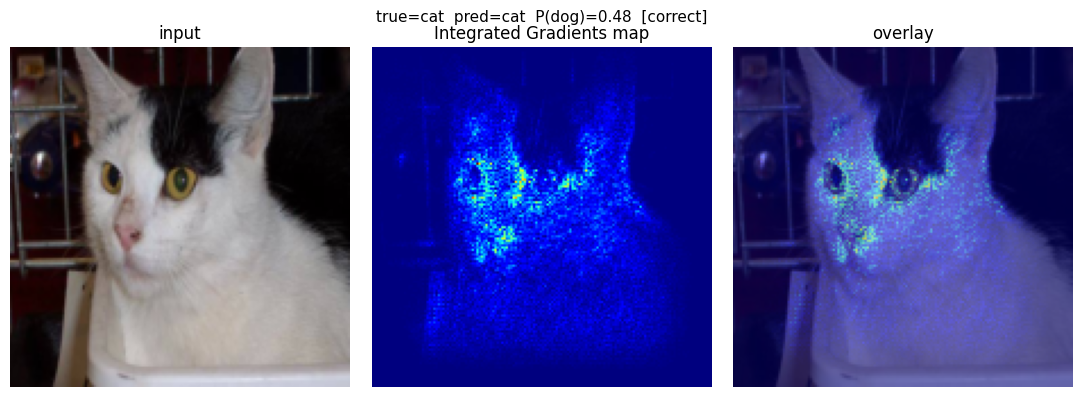

In [72]:
# Integrated Gradients: image 2
r = examples[1]
ig_maps.append(integrated_gradients_map(r["x"], target=r["pred"]))
show_overlay(r, ig_maps[1], method="Integrated Gradients")

Attribution spreads across the face with the eyes brightest. This fits the model's low confidence .

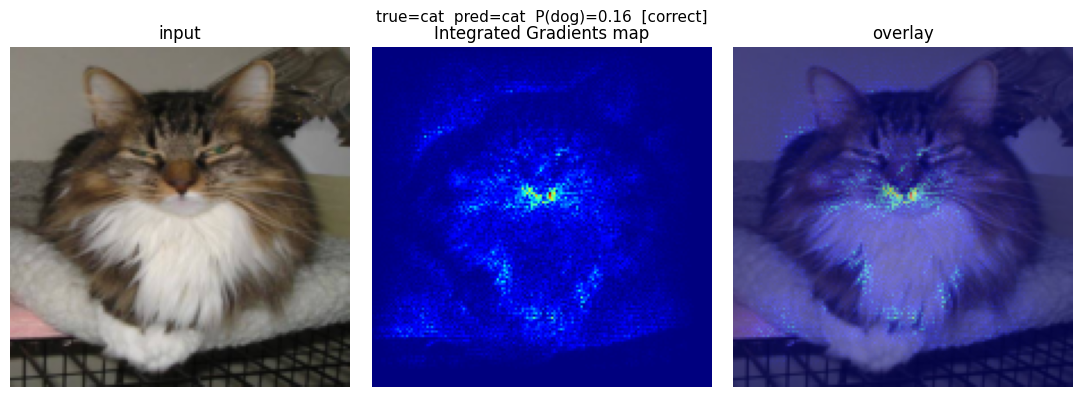

In [73]:
# Integrated Gradients: image 3
r = examples[2]
ig_maps.append(integrated_gradients_map(r["x"], target=r["pred"]))
show_overlay(r, ig_maps[2], method="Integrated Gradients")

Tight hotspot on the eyes and nose. The model attended to the central face.

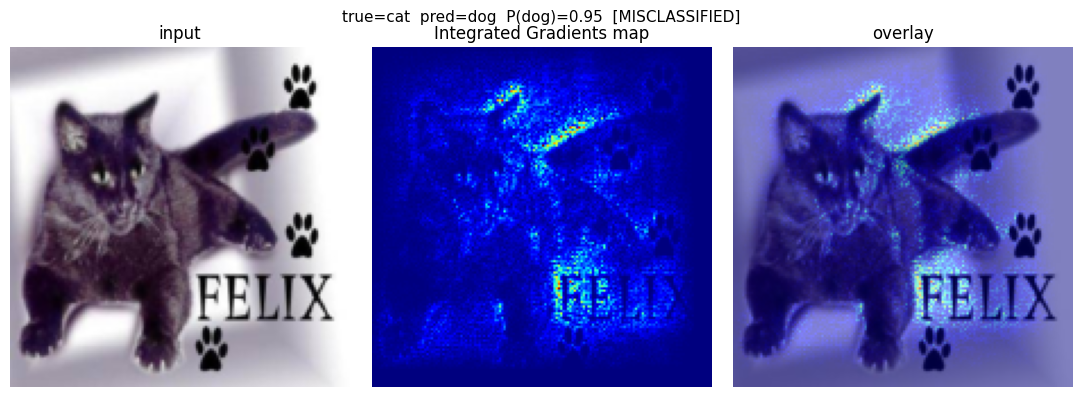

In [74]:
# Integrated Gradients: image 4 (misclassified)
r = examples[3]
ig_maps.append(integrated_gradients_map(r["x"], target=r["pred"]))
show_overlay(r, ig_maps[3], method="Integrated Gradients")

Attribution lands on the leg and background, not the face. The model keyed on the odd pose, not cat features.

Method 2: Grad-CAM

Grad-CAM finds which regions of the image mattered for the prediction. It takes the last convolutional layer's feature maps, weights each by its importance to the predicted class, and combines them into one heatmap. The result shows where the model looked.

The layer the Grad-CAM runs on is deep enough to carry meaning about the class but still keeps spatial layout, so the heatmap can point to where in the image the evidence is. Earlier layers give sharper but less meaningful maps.

The heatmap is low resolution. After four pooling layers a 150×150 image becomes a 7×7 feature map, so each cell covers a large patch. Upsampling gives a blob that shows the right region but can't pinpoint very fine detail.

In [75]:
gradcam = LayerGradCam(wrapped, target_layer)

def grad_cam_map(x, target):
    attr = gradcam.attribute(x, target=target, relu_attributions=True)
    attr = LayerAttribution.interpolate(attr, (IMG_SIZE, IMG_SIZE))
    attr = attr.squeeze().detach().cpu().numpy()
    return attr / (attr.max() + 1e-8)

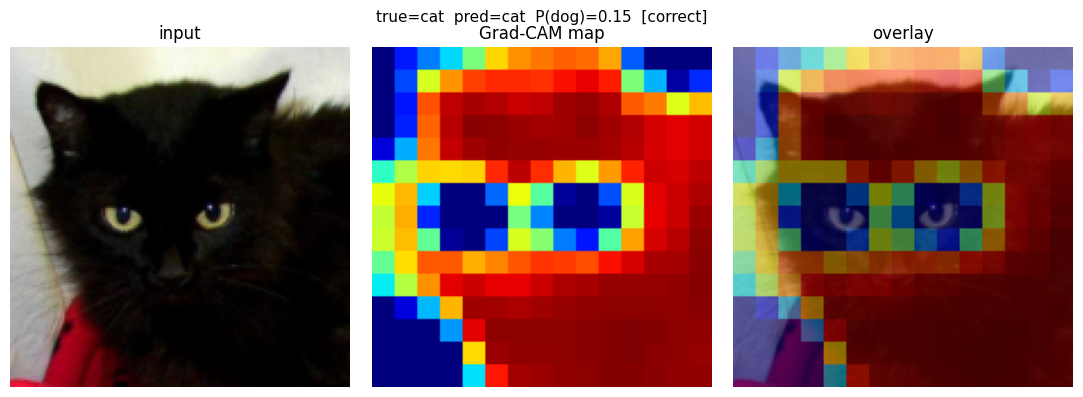

In [76]:
# Grad-CAM: image 1
r = examples[0]
cam_maps = [grad_cam_map(r["x"], target=r["pred"])]
show_overlay(r, cam_maps[0], method="Grad-CAM")

Warm region covers the head and upper body. The model localized the cat's head.

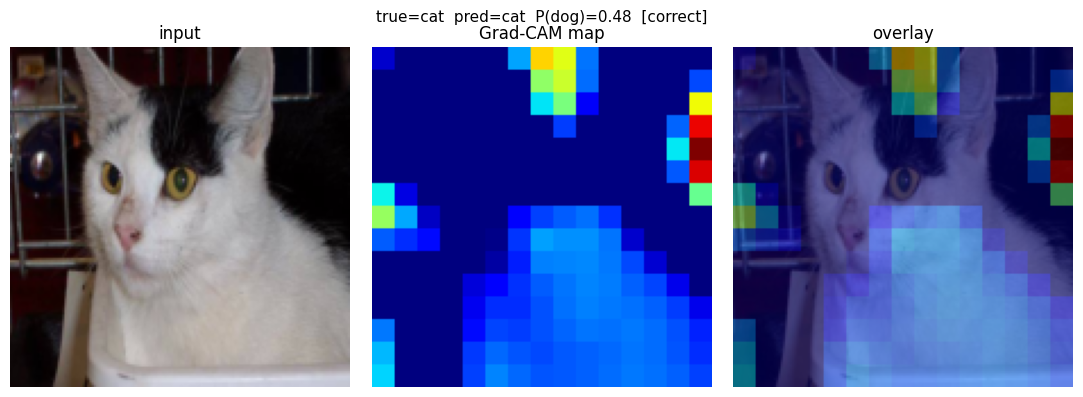

In [77]:
# Grad-CAM: image 2
r = examples[1]
cam_maps.append(grad_cam_map(r["x"], target=r["pred"]))
show_overlay(r, cam_maps[1], method="Grad-CAM")

Mostly cool over the face, warm spots around the edges of face. Weak heat fits the low-confidence.

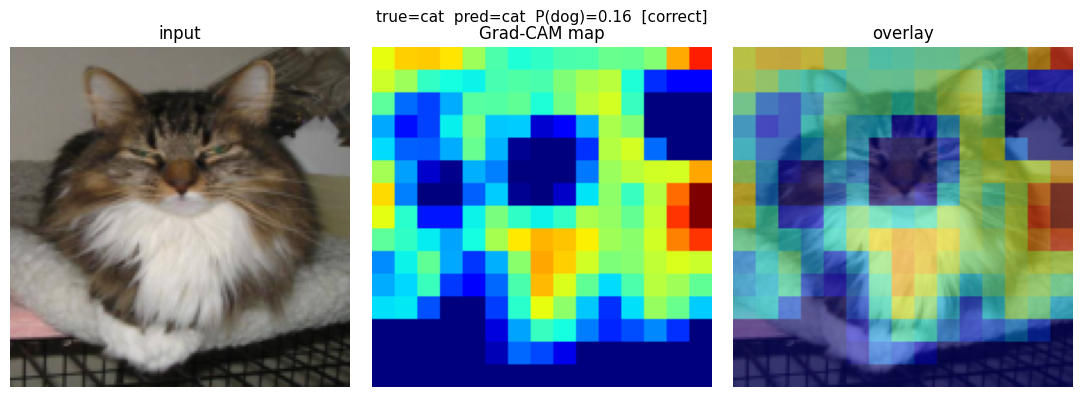

In [78]:
# Grad-CAM: image 3
r = examples[2]
cam_maps.append(grad_cam_map(r["x"], target=r["pred"]))
show_overlay(r, cam_maps[2], method="Grad-CAM")

Warm region sits over the lower face and most of the cat.

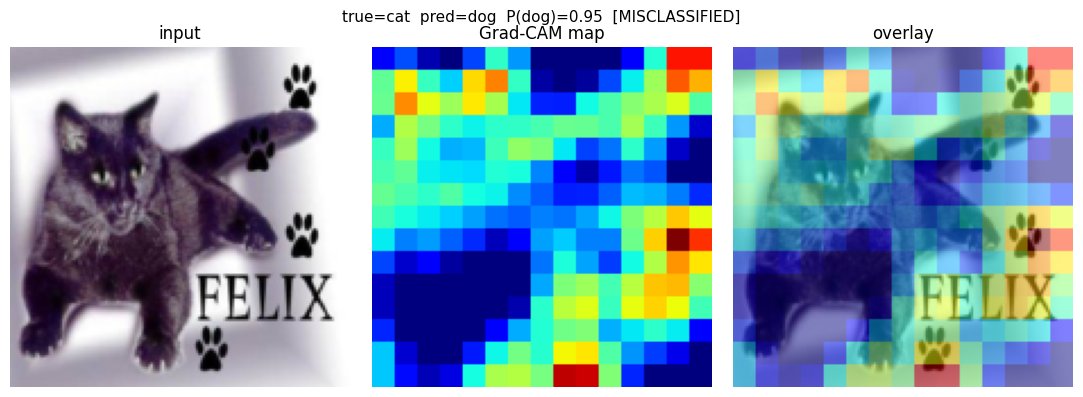

In [79]:
# Grad-CAM: image 4 (misclassified)
r = examples[3]
cam_maps.append(grad_cam_map(r["x"], target=r["pred"]))
show_overlay(r, cam_maps[3], method="Grad-CAM")

Warm blocks go to the edges and watermark instead of locking onto the face.

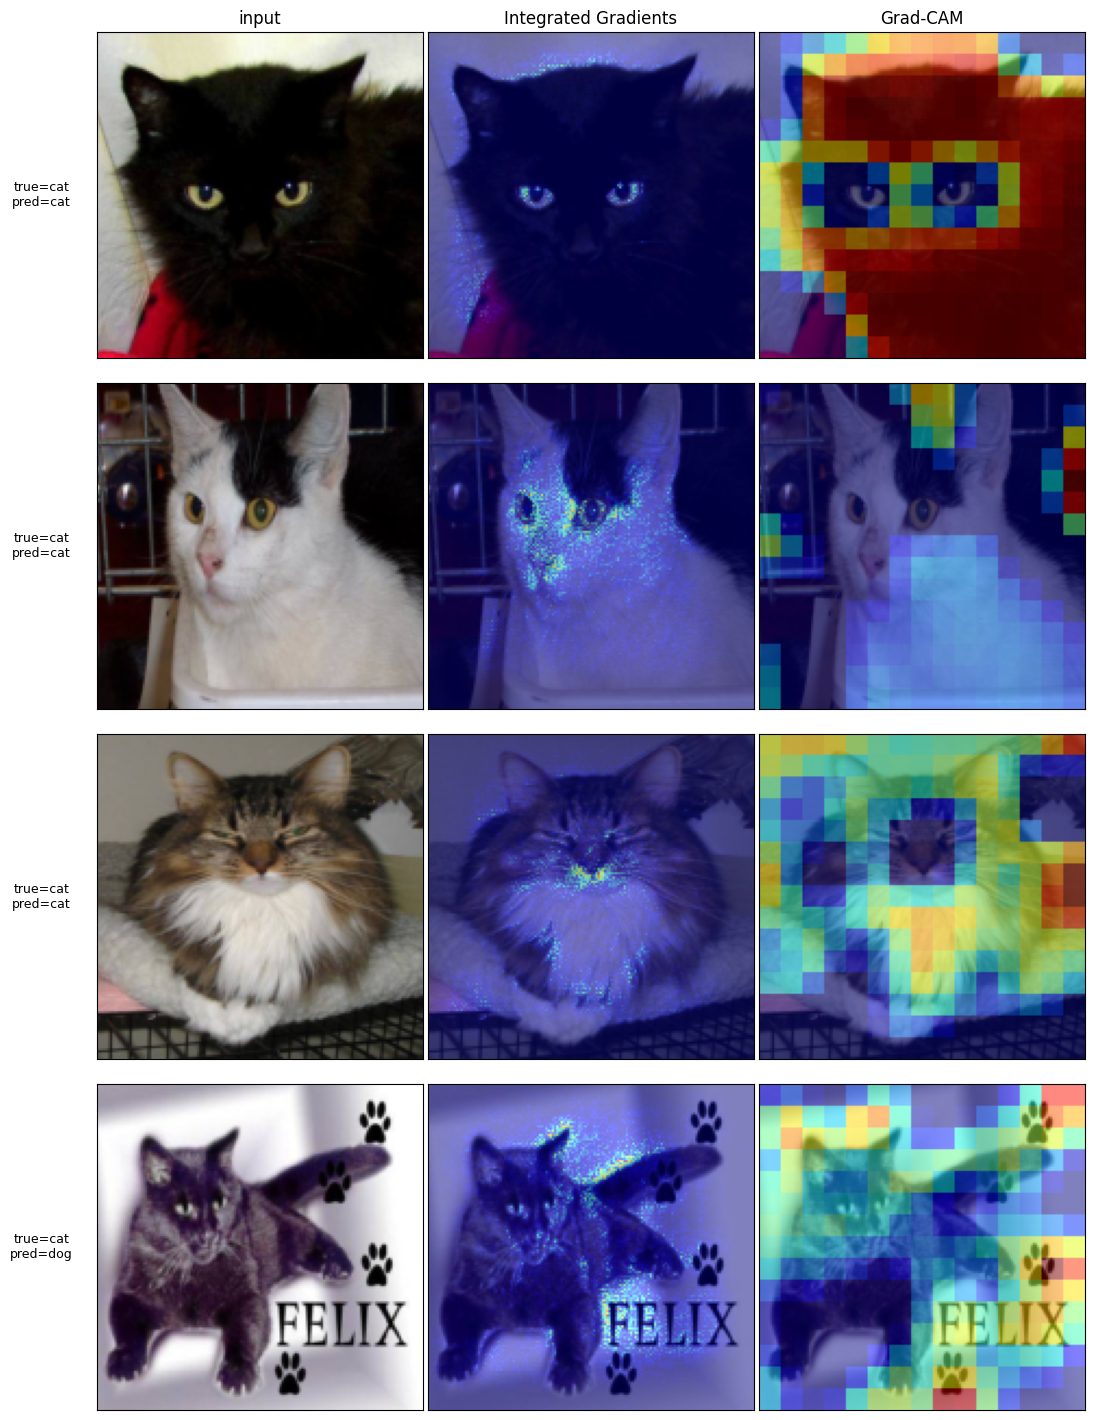

In [80]:
fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3.6 * len(examples)))
if len(examples) == 1:
    axes = axes[None, :]

for row, (r, ig_a, cam_a) in enumerate(zip(examples, ig_maps, cam_maps)):
    base = denormalize(r["x"].squeeze(0))
    axes[row, 0].imshow(base)
    axes[row, 0].set_ylabel(
        f"true={label_names[r['true']]}\npred={label_names[r['pred']]}",
        fontsize=9, rotation=0, labelpad=40, va="center")
    axes[row, 0].set_title("input" if row == 0 else "")
    axes[row, 1].imshow(base); axes[row, 1].imshow(ig_a, cmap="jet", alpha=0.5)
    axes[row, 1].set_title("Integrated Gradients" if row == 0 else "")
    axes[row, 2].imshow(base); axes[row, 2].imshow(cam_a, cmap="jet", alpha=0.5)
    axes[row, 2].set_title("Grad-CAM" if row == 0 else "")
    for c in range(3):
        axes[row, c].set_xticks([]); axes[row, c].set_yticks([])

plt.tight_layout(); plt.show()

On the correct cats the two methods mostly agree, both landing on the face. Integrated Gradients points right at the eyes, while Grad-CAM lights up the whole head, since it works at a 7×7 resolution. The big difference is detail as the Integrated Gradient uses pixels which look sharp, and Grad-CAM uses regions which can be blurry. On the misclassified cat both maps move off the face onto the stretched pose and the watermark, which is probably why the model wrongly guessed dog.